# Capítulo 5 - Análise Preditiva

## KNN para Prever Diabetes
kaggle: https://www.kaggle.com/code/umairziact/diabetes-dataset


In [5]:
pip install pandas

  Using cached pandas-3.0.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached numpy-2.5.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached pandas-3.0.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.0 MB)
Using cached numpy-2.5.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd

In [7]:
df = pd.read_csv('diabetes_prediction.csv')

In [8]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
0,2,115.863387,56.410731,24.336736,94.385783,26.455940,0.272682,20.100494,0
1,2,92.490122,70.615520,23.443591,138.652426,23.910167,0.665160,44.912281,0
2,1,88.141469,63.262618,23.404364,149.358082,21.948250,0.676022,48.247873,1
3,2,108.453101,67.793632,20.751580,108.751638,24.209304,0.289636,42.749868,0
4,1,127.849443,94.725685,22.603078,25.269987,32.997477,0.601315,32.797789,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1000 non-null   int64  
 1   Glucose                   1000 non-null   float64
 2   BloodPressure             1000 non-null   float64
 3   SkinThickness             1000 non-null   float64
 4   Insulin                   1000 non-null   float64
 5   BMI                       1000 non-null   float64
 6   DiabetesPedigreeFunction  1000 non-null   float64
 7   Age                       1000 non-null   float64
 8   Diagnosis                 1000 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 70.4 KB


In [ ]:
# Diagnosis refere-se ao paiciente e verifica se ele possui ou não diabetes.

In [13]:
# Análises descritivas básicas como [count → quantidade], [mean  → média], 
# [std   → dispersão], [min   → menor], [25%   → Q1], [50%   → mediana],
# [75%   → Q3], [max   → maior]

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1.771000,99.440607,72.179837,23.278316,84.582679,25.433600,0.449383,43.281798,0.30600
std,1.354398,19.470730,13.882017,1.173807,74.872733,3.690223,0.199334,14.465398,0.46106
min,0.000000,30.571402,31.401487,19.369987,-165.310033,13.548818,0.100037,-0.979804,0.00000
25%,1.000000,86.145927,62.795447,22.501591,35.076535,23.022715,0.283376,33.518451,0.00000
50%,2.000000,99.458362,71.909588,23.275225,84.442232,25.455649,0.448219,43.634273,0.00000
75%,3.000000,113.264556,82.082660,24.052022,134.267842,27.972184,0.619158,53.098446,1.00000
max,8.000000,161.238939,110.723715,26.917654,317.701852,36.324598,0.799654,90.573782,1.00000


In [15]:
# correlação entre os atributos
# O target é 'Diagnosis', ou seja, o ideal é checar a correlação entre ele e
# os outros atributos e entender o que pode se mais relevante para o nosso
# problema.
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
Pregnancies,1.000000,0.011362,0.077683,-0.040438,-0.020708,-0.006228,-0.001419,0.088453,-0.001484
Glucose,0.011362,1.000000,0.010261,0.002874,-0.010334,0.002024,0.005122,-0.003056,-0.004971
BloodPressure,0.077683,0.010261,1.000000,-0.038723,0.044350,-0.000791,-0.007349,0.049709,0.010349
SkinThickness,-0.040438,0.002874,-0.038723,1.000000,0.044425,0.062209,-0.054404,-0.047309,-0.000014
Insulin,-0.020708,-0.010334,0.044350,0.044425,1.000000,0.044684,-0.026908,0.037062,0.035411
BMI,-0.006228,0.002024,-0.000791,0.062209,0.044684,1.000000,-0.020680,-0.066314,-0.033336
DiabetesPedigreeFunction,-0.001419,0.005122,-0.007349,-0.054404,-0.026908,-0.020680,1.000000,0.017163,0.060549
Age,0.088453,-0.003056,0.049709,-0.047309,0.037062,-0.066314,0.017163,1.000000,-0.044726
Diagnosis,-0.001484,-0.004971,0.010349,-0.000014,0.035411,-0.033336,0.060549,-0.044726,1.000000


In [ ]:
# Conseguimos identificar que as colunas possuem relação entre si e nesse caso,
# iremos isolá-las.

# 'Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction'
selected_features = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
x = df[selected_features]
y = df['Diagnosis']

0      0
1      0
2      1
3      0
4      0
      ..
995    0
996    1
997    1
998    0
999    1
Name: Diagnosis, Length: 1000, dtype: int64

In [22]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 9.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 16.9 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# separar BASE DE DADOS em treino e teste
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [27]:
# ANÁLISE PREDITIVA - KNN
# instanciando o modelo KNN com 5 vizinhos
knn = KNeighborsClassifier(n_neighbors=5)

# treinando o modelo com os dados de treino
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [28]:
# Predição com os dados de teste
knn_predictions = knn.predict(X_test)

# Avaliando a acurácia do modelo
knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_accuracy

0.615

In [31]:
# Para verificar se há valor de k que seja melhor para a situação testada
knn_lista = []
k_lista = []

for k in range(1, 20, 2):
	knn = KNeighborsClassifier(n_neighbors=k)
	knn.fit(X_train, y_train)
	knn_predictions = knn.predict(X_test)
	knn_accuracy = accuracy_score(y_test, knn_predictions)

	knn_lista.append(knn_accuracy)
	k_lista.append(k)

knn_lista

[0.545, 0.62, 0.615, 0.675, 0.66, 0.675, 0.67, 0.685, 0.69, 0.68]

In [32]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 10.1 MB/s  0:00:00eta 0:00:01m
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 10.7 MB/s  0:00:00 eta 0:00:01
Using cached kiwisolver-1.5.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.5 MB)
Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.9 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


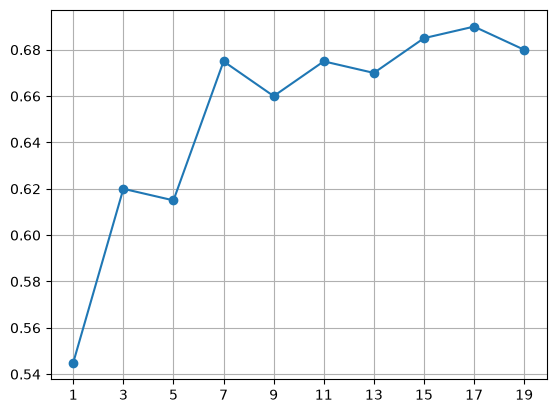

In [33]:
import matplotlib.pyplot as plt

plt.grid()
plt.xticks(k_lista)
plt.plot(k_lista, knn_lista, marker='o')